# Minor groove witdh profiles with mean and standard deviation values

## DNMT3A

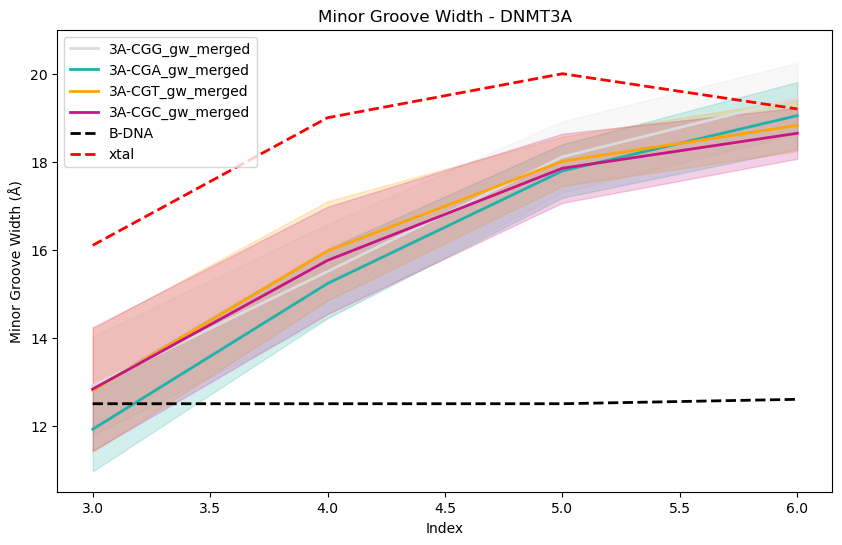

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

input_files = os.path.join('DNMT3A_inputs')
file_paths = glob.glob(input_files+"/*_gw_merged")

# Initialize a dictionary to store dataframes
data_dict = {}

# Load all CSV files into a dictionary
for file in file_paths:
    df = pd.read_csv(file, delimiter=";", names=["index", "minor_groove", "major_groove"])
    data_dict[file] = df

# Load the reference CSV file
reference_file = input_files+"/b-dna_ref.csv"
reference_df = pd.read_csv(reference_file, delimiter=";", names=["index", "major", "minor"])

reference_file_2 = input_files+"/b-3a-cgc_groove.csv"
reference_df_2 = pd.read_csv(reference_file_2, delimiter=";", names=["index", "minor", "major"])

# Define specific colors for specific filename patterns
color_map = {
    "3A-CGT": "orange",
    "3A-CGC": "#C71585",
    "3A-CGA": "lightseagreen",
    "3A-CGG": "#DCDCDC",
}

plt.figure(figsize=(10, 6))

for i, (file_name, df) in enumerate(data_dict.items()):
    if "3A" in file_name:
        df["index"] = pd.to_numeric(df["index"], errors='coerce')
        df["minor_groove"] = pd.to_numeric(df["minor_groove"], errors='coerce')

        grouped_df = df.groupby("index")["minor_groove"].agg(["mean", "std"]).reset_index()

        x = grouped_df["index"]
        y_mean = grouped_df["mean"]
        y_std = grouped_df["std"]

        file_key = os.path.basename(file_name)
        color = None
        for keyword, assigned_color in color_map.items():
            if keyword in file_key:
                color = assigned_color

        plt.plot(x, y_mean, label=file_key, color=color, linewidth=2)

        # Shaded region for standard deviation
        plt.fill_between(x, y_mean - y_std, y_mean + y_std, color=color, alpha=0.2)

plt.plot(reference_df["index"], reference_df["minor"], label="B-DNA", color="black", linestyle="--", linewidth=2)

plt.plot(reference_df_2["index"], reference_df_2["minor"], label="xtal", color="red", linestyle="--", linewidth=2)

plt.xlabel("Index")
plt.ylabel("Minor Groove Width (Å)")
plt.title("Minor Groove Width - DNMT3A")
plt.legend(loc="upper left")
plt.ylim(ymax=21, ymin=10.5)
plt.savefig("3a_minor.png", dpi=300)

## DNMT3B

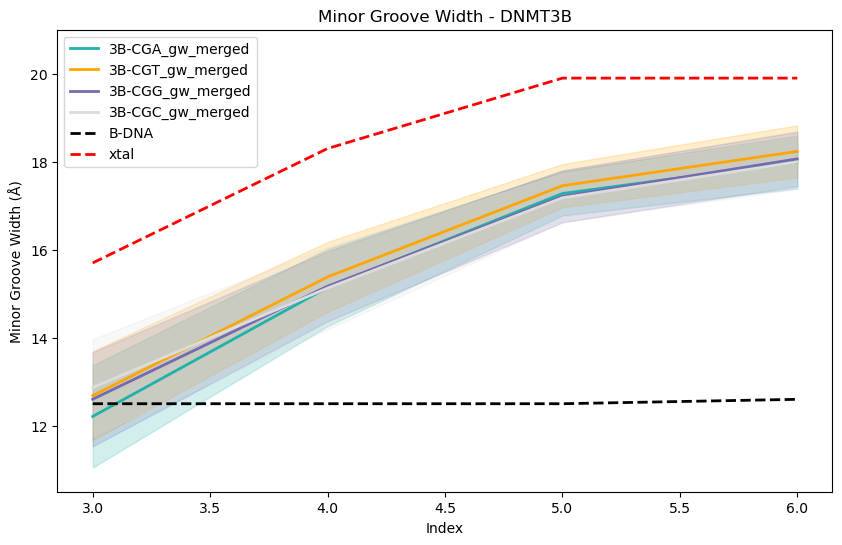

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

input_files = os.path.join('DNMT3B_inputs')
file_paths = glob.glob(input_files+"/*_gw_merged")

# Initialize a dictionary to store dataframes
data_dict = {}

# Load all CSV files into a dictionary
for file in file_paths:
    df = pd.read_csv(file, delimiter=";", names=["index", "minor_groove", "major_groove"])
    data_dict[file] = df

# Load the reference CSV file
reference_file = input_files+"/b-dna_ref.csv"
reference_df = pd.read_csv(reference_file, delimiter=";", names=["index", "major", "minor"])

reference_file_2 = input_files+"/b-3b-cgg_groove.csv"
reference_df_2 = pd.read_csv(reference_file_2, delimiter=";", names=["index", "minor", "major"])

# Define specific colors for specific filename patterns
color_map = {
    "3B-CGT": "orange",
    "3B-CGC": "#DCDCDC",
    "3B-CGA": "lightseagreen",
    "3B-CGG": "#746AB0",
}

plt.figure(figsize=(10, 6))

for i, (file_name, df) in enumerate(data_dict.items()):
    if "3B" in file_name:
        df["index"] = pd.to_numeric(df["index"], errors='coerce')
        df["minor_groove"] = pd.to_numeric(df["minor_groove"], errors='coerce')

        grouped_df = df.groupby("index")["minor_groove"].agg(["mean", "std"]).reset_index()

        x = grouped_df["index"]
        y_mean = grouped_df["mean"]
        y_std = grouped_df["std"]

        file_key = os.path.basename(file_name)
        color = None
        for keyword, assigned_color in color_map.items():
            if keyword in file_key:
                color = assigned_color

        plt.plot(x, y_mean, label=file_key, color=color, linewidth=2)

        # Shaded region for standard deviation
        plt.fill_between(x, y_mean - y_std, y_mean + y_std, color=color, alpha=0.2)

plt.plot(reference_df["index"], reference_df["minor"], label="B-DNA", color="black", linestyle="--", linewidth=2)

plt.plot(reference_df_2["index"], reference_df_2["minor"], label="xtal", color="red", linestyle="--", linewidth=2)

plt.xlabel("Index")
plt.ylabel("Minor Groove Width (Å)")
plt.title("Minor Groove Width - DNMT3B")
plt.legend(loc="upper left")
plt.ylim(ymax=21, ymin=10.5)
plt.savefig("3b_minor.png", dpi=300)